# SDV Models: Comprehensive Evaluation — Adult Census Income

This notebook evaluates four synthetic data generation models on the **Adult Census Income** dataset (`Datasets/adult_census.csv`):
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using:
- **Fidelity** metrics: KS complement, Wasserstein distance, JS divergence, Gower distance, MMD, cosine similarity, ANN distance
- **Utility** metrics: TSTR/TRTR with 10 classifiers (AUC, Accuracy, F1, Precision, Recall, PR-AUC)
- **Structural** analysis: bivariate Δ-correlation, t-SNE, PCA + clustering
- **Privacy** assessment: Cosine + Hungarian mapping, Mahalanobis matching

**Target variable**: `income` (binary: `<=50K` / `>=50K`)


## 1. Data Loading and Setup


In [1]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Locate adult_census.csv (works when run from Notebooks/ or project root)
_csv_paths = [
    'Datasets/adult_census.csv',
    '../Datasets/adult_census.csv',
]
csv_path = next((p for p in _csv_paths if os.path.exists(p)), None)
if csv_path is None:
    raise FileNotFoundError('adult_census.csv not found. Expected in Datasets/ or ../Datasets/')

adult_data = pd.read_csv(csv_path)

# Normalize column names (some versions use different names)
adult_data = adult_data.rename(columns={
    'gender': 'sex',
    'educational-num': 'education-num',
})

# Strip leading/trailing whitespace from string columns
adult_data = adult_data.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

# Replace '?' with NaN (Adult dataset missing-value marker)
adult_data = adult_data.replace('?', np.nan)

if 'income' not in adult_data.columns:
    raise KeyError("Column 'income' not found in dataset")

# Normalise income labels: strip trailing dot, map >50K -> >=50K
adult_data['income'] = (
    adult_data['income']
    .astype(str)
    .str.replace(r'\.$', '', regex=True)
    .replace({'>50K': '>=50K', '<=50K': '<=50K'})
)

print('Data shape:', adult_data.shape)
print('Columns:', list(adult_data.columns))
print('\nIncome distribution:')
print(adult_data['income'].value_counts(dropna=False))
print('\nMissing values per column:')
print(adult_data.isnull().sum()[adult_data.isnull().sum() > 0])

Data shape: (48842, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Income distribution:
income
<=50K    37155
>=50K    11687
Name: count, dtype: int64

Missing values per column:
workclass         2799
occupation        2809
native-country     857
dtype: int64


## 2. Sample + SDV Metadata


In [4]:
import pandas as pd
import numpy as np
from sdv.metadata import SingleTableMetadata

# -----------------------------
# Settings
# -----------------------------
SAMPLE_SIZE = 10_000
label_col = 'income'

# -----------------------------
# Clean dataset
# -----------------------------
adult_clean = adult_data.dropna().reset_index(drop=True)

# -----------------------------
# Binary Encoding (IMPORTANT)
# -----------------------------
adult_clean[label_col] = adult_clean[label_col].apply(
    lambda x: 1 if str(x).strip() in ['>=50K', '>50K', '1'] else 0
)

# -----------------------------
# Stratified Sampling
# -----------------------------
if len(adult_clean) > SAMPLE_SIZE:
    
    proportions = adult_clean[label_col].value_counts(normalize=True)
    
    adult_sample = (
        adult_clean
        .groupby(label_col, group_keys=False)
        .apply(lambda g: g.sample(
            n=max(1, int(SAMPLE_SIZE * proportions[g.name])),
            random_state=42
        ))
        .reset_index(drop=True)
    )
    
    # Top-up if needed
    if len(adult_sample) < SAMPLE_SIZE:
        remaining = adult_clean.drop(adult_sample.index)
        adult_sample = pd.concat(
            [
                adult_sample,
                remaining.sample(SAMPLE_SIZE - len(adult_sample), random_state=42)
            ],
            ignore_index=True
        )

else:
    adult_sample = adult_clean.copy()

# -----------------------------
# Debug info
# -----------------------------
print('Sample shape:', adult_sample.shape)
print('\nIncome distribution (binary):')
print(adult_sample[label_col].value_counts())

# -----------------------------
# SDV Metadata
# -----------------------------
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(adult_sample)

# Set as categorical (important even if 0/1)
metadata.update_column(column_name=label_col, sdtype='categorical')

# -----------------------------
# Numeric columns
# -----------------------------
NUMERIC_COLS = adult_sample.select_dtypes(include=[np.number]).columns.tolist()

print('\nNumeric columns:', NUMERIC_COLS)
print(f'\nMetadata detected. Total columns: {len(adult_sample.columns)}')

Sample shape: (10000, 15)

Income distribution (binary):
income
0    7522
1    2478
Name: count, dtype: int64

Numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']

Metadata detected. Total columns: 15


In [5]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")

In [6]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

def bivariate_quality_cancer(real_df, synth_df, target='diagnosis'):
    """Compute bivariate quality metrics for cancer data."""
    num_cols = [c for c in real_df.columns if c != target]
    
    # Min-Max scaling on numeric columns
    scaler = MinMaxScaler()
    
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()
    
    # Fit on real, transform both real and synthetic
    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])
    
    results_corr = []
    results_target = []

    # Numeric-to-numeric: Δ-correlation
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            'var_a': a,
            'var_b': b,
            'delta_corr': abs(r_corr - s_corr)
        })
    
    # Numeric-to-target: Δ-Wasserstein between classes
    for col in num_cols:
        r_groups = [g[col].values for _, g in real_scaled.groupby(target)]
        s_groups = [g[col].values for _, g in synth_scaled.groupby(target)]
        
        if len(r_groups) == 2 and len(s_groups) == 2:
            d_real = stats.wasserstein_distance(*r_groups)
            d_synth = stats.wasserstein_distance(*s_groups)
            results_target.append({
                "feature": col,
                "delta_wasserstein": abs(d_real - d_synth)
            })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False)
    
    return corr_df, target_df

# 2. Generating synthetic data

In [8]:
import pandas as pd
import numpy as np

from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

# --------------------------------------------------
# Models
# --------------------------------------------------
SDV_MODELS = {
    'CTGAN': CTGANSynthesizer,
    'CopulaGAN': CopulaGANSynthesizer,
    'TVAE': TVAESynthesizer,
    'GaussianCopula': GaussianCopulaSynthesizer,
}

synthetic_data = {}
diagnostics = {}
quality_reports = {}

# --------------------------------------------------
# Helper: Match class distribution
# --------------------------------------------------
def resample_to_match_class_ratio(real_df, synth_df, target_col, random_state=42):
    real_counts = real_df[target_col].value_counts().sort_index()
    parts = []

    for cls, n in real_counts.items():
        subset = synth_df[synth_df[target_col] == cls]

        if len(subset) == 0:
            print(f"Warning: No samples for class {cls} in synthetic data")
            continue

        replace = len(subset) < n
        parts.append(
            subset.sample(n=int(n), replace=replace, random_state=random_state)
        )

    if not parts:
        return synth_df

    return (
        pd.concat(parts, ignore_index=True)
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )

# --------------------------------------------------
# Synthesis
# --------------------------------------------------
NUM_SYNTH = len(adult_sample)

for model_key, SynthClass in SDV_MODELS.items():
    print(f'\n{"-"*60}')
    print(f'Training {model_key}...')

    try:
        # Optional tuning (safe defaults)
        if model_key in ['CTGAN', 'CopulaGAN']:
            synth_model = SynthClass(metadata=metadata, epochs=300)
        elif model_key == 'TVAE':
            synth_model = SynthClass(metadata=metadata, epochs=300)
        else:
            synth_model = SynthClass(metadata=metadata)

        # Train
        synth_model.fit(adult_sample)

        # Generate synthetic data
        raw_synth = synth_model.sample(NUM_SYNTH)

        # Match class distribution
        balanced_synth = resample_to_match_class_ratio(
            adult_sample, raw_synth, label_col, random_state=42
        )

        synthetic_data[model_key] = balanced_synth

        print(f'  Class distribution: {balanced_synth[label_col].value_counts().to_dict()}')

        # Diagnostics
        diagnostics[model_key] = run_diagnostic(
            adult_sample, balanced_synth, metadata
        )

        # Quality report
        quality_reports[model_key] = evaluate_quality(
            adult_sample, balanced_synth, metadata
        )

        print(f'  {model_key} completed successfully.')

    except Exception as e:
        print(f'  ERROR ({model_key}): {e}')

# --------------------------------------------------
# Summary
# --------------------------------------------------
print('\n=== Synthesis Complete ===')
for k in synthetic_data:
    print(f'  {k}: {synthetic_data[k].shape}')


------------------------------------------------------------
Training CTGAN...
  Class distribution: {0: 7522, 1: 2478}
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 15/15 [00:00<00:00, 680.72it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<?, ?it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 306.55it/s]|
Column Shapes Score: 89.71%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 201.48it/s]|
Column Pair Trends Score: 85.59%

Overall Score (Average): 87.65%

  CTGAN completed successfully.

------------------------------------------------------------
Training CopulaGAN...
  Class distribution: {0: 7522, 1: 2478}
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 15/15 [00:00<00:00, 961.92it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1

# 3. TRTR/TSTR Evaluation

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    precision_score, recall_score, average_precision_score
)

# --------------------------------------------------
# Classifiers
# --------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

classifiers_dict = {
    'LogReg':        LogisticRegression(max_iter=5000, solver='liblinear', class_weight='balanced', random_state=42),
    'SVM-RBF':       SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    'KNN':           KNeighborsClassifier(),
    'NaiveBayes':    GaussianNB(),
    'DecisionTree':  DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'RandomForest':  RandomForestClassifier(class_weight='balanced', random_state=42),
    'ExtraTrees':    ExtraTreesClassifier(class_weight='balanced', random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    'AdaBoost':      AdaBoostClassifier(random_state=42),
    'MLP':           MLPClassifier(max_iter=2000, random_state=42),
}

# --------------------------------------------------
# Split REAL data
# --------------------------------------------------
X = adult_sample.drop(columns=[label_col])
y = adult_sample[label_col]

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# --------------------------------------------------
# Preprocessing
# --------------------------------------------------
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

# --------------------------------------------------
# Metric function
# --------------------------------------------------
def compute_metrics(y_true, y_pred, y_prob):
    return {
        'AUC': roc_auc_score(y_true, y_prob),
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'PRAUC': average_precision_score(y_true, y_prob),
    }

# --------------------------------------------------
# Evaluation Loop
# --------------------------------------------------
results = []

for model_name, model in classifiers_dict.items():
    print(f"\nEvaluating {model_name}...")

    try:
        # TRTR
        pipe_trtr = Pipeline([
            ('prep', preprocessor),
            ('model', model)
        ])
        pipe_trtr.fit(X_train_real, y_train_real)

        y_pred_trtr = pipe_trtr.predict(X_test_real)
        y_prob_trtr = pipe_trtr.predict_proba(X_test_real)[:, 1]

        trtr_metrics = compute_metrics(y_test_real, y_pred_trtr, y_prob_trtr)

        # TSTR
        for synth_name, synth_df in synthetic_data.items():

            X_synth = synth_df.drop(columns=[label_col])
            y_synth = synth_df[label_col]

            pipe_tstr = Pipeline([
                ('prep', preprocessor),
                ('model', model)
            ])

            pipe_tstr.fit(X_synth, y_synth)

            y_pred_tstr = pipe_tstr.predict(X_test_real)
            y_prob_tstr = pipe_tstr.predict_proba(X_test_real)[:, 1]

            tstr_metrics = compute_metrics(y_test_real, y_pred_tstr, y_prob_tstr)

            row = {'Model': f"{model_name} ({synth_name})"}

            for k in trtr_metrics:
                row[f"{k}_TRTR"] = trtr_metrics[k]
                row[f"{k}_TSTR"] = tstr_metrics[k]

            results.append(row)

        print("Done")

    except Exception as e:
        print(f"Error: {e}")

# --------------------------------------------------
# Final Results
# --------------------------------------------------
results_df = pd.DataFrame(results)

print("\nEvaluation Complete")
display(results_df.round(4))


Evaluating LogReg...
Done

Evaluating SVM-RBF...
Done

Evaluating KNN...
Done

Evaluating NaiveBayes...
Error: Sparse data was passed for X, but dense data is required. Use '.toarray()' to convert to a dense numpy array.

Evaluating DecisionTree...
Done

Evaluating RandomForest...
Done

Evaluating ExtraTrees...
Done

Evaluating GradientBoost...
Done

Evaluating AdaBoost...
Done

Evaluating MLP...
Done

Evaluation Complete


,Model,AUC_TRTR,AUC_TSTR,Accuracy_TRTR,Accuracy_TSTR,F1_TRTR,F1_TSTR,Precision_TRTR,Precision_TSTR,Recall_TRTR,Recall_TSTR,PRAUC_TRTR,PRAUC_TSTR
0,LogReg (CTGAN),0.9065,0.8709,0.8180,0.7410,0.6929,0.6255,0.5952,0.4872,0.8291,0.8735,0.7786,0.6828
1,LogReg (CopulaGAN),0.9065,0.8780,0.8180,0.7810,0.6929,0.6489,0.5952,0.5381,0.8291,0.8170,0.7786,0.7131
2,LogReg (TVAE),0.9065,0.8995,0.8180,0.7983,0.6929,0.6773,0.5952,0.5610,0.8291,0.8546,0.7786,0.7598
3,LogReg (GaussianCopula),0.9065,0.8439,0.8180,0.7213,0.6929,0.5926,0.5952,0.4645,0.8291,0.8183,0.7786,0.6876
4,SVM-RBF (CTGAN),0.6302,0.5902,0.7927,0.6663,0.2834,0.3313,0.9840,0.3289,0.1655,0.3338,0.4808,0.3728
5,SVM-RBF (CopulaGAN),0.6302,0.6328,0.7927,0.7643,0.2834,0.2597,0.9840,0.5849,0.1655,0.1669,0.4808,0.4272
6,SVM-RBF (TVAE),0.6302,0.5687,0.7927,0.6343,0.2834,0.3451,0.9840,0.3101,0.1655,0.3890,0.4808,0.4123
7,SVM-RBF (GaussianCopula),0.6302,0.5483,0.7927,0.4827,0.2834,0.3717,0.9840,0.2658,0.1655,0.6178,0.4808,0.3221
8,KNN (CTGAN),0.6197,0.5972,0.7633,0.7253,0.3580,0.3213,0.5455,0.4140,0.2665,0.2624,0.4119,0.3686
9,KNN (CopulaGAN),0.6197,0.5861,0.7633,0.7203,0.3580,0.2908,0.5455,0.3909,0.2665,0.2315,0.4119,0.3187


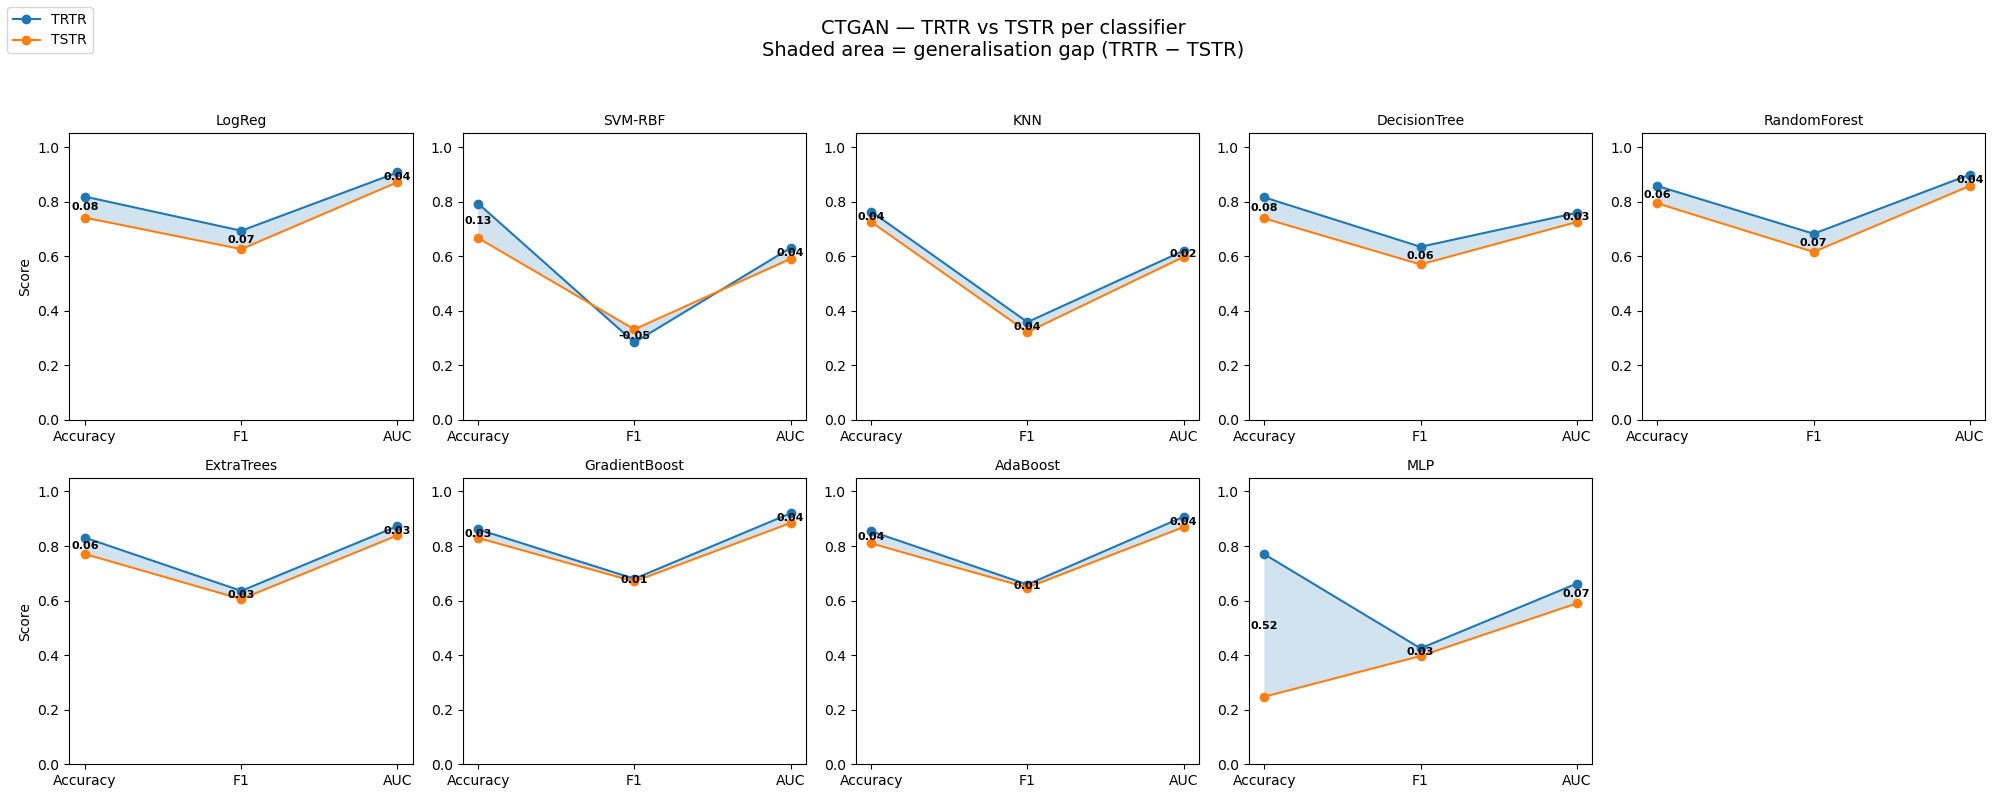

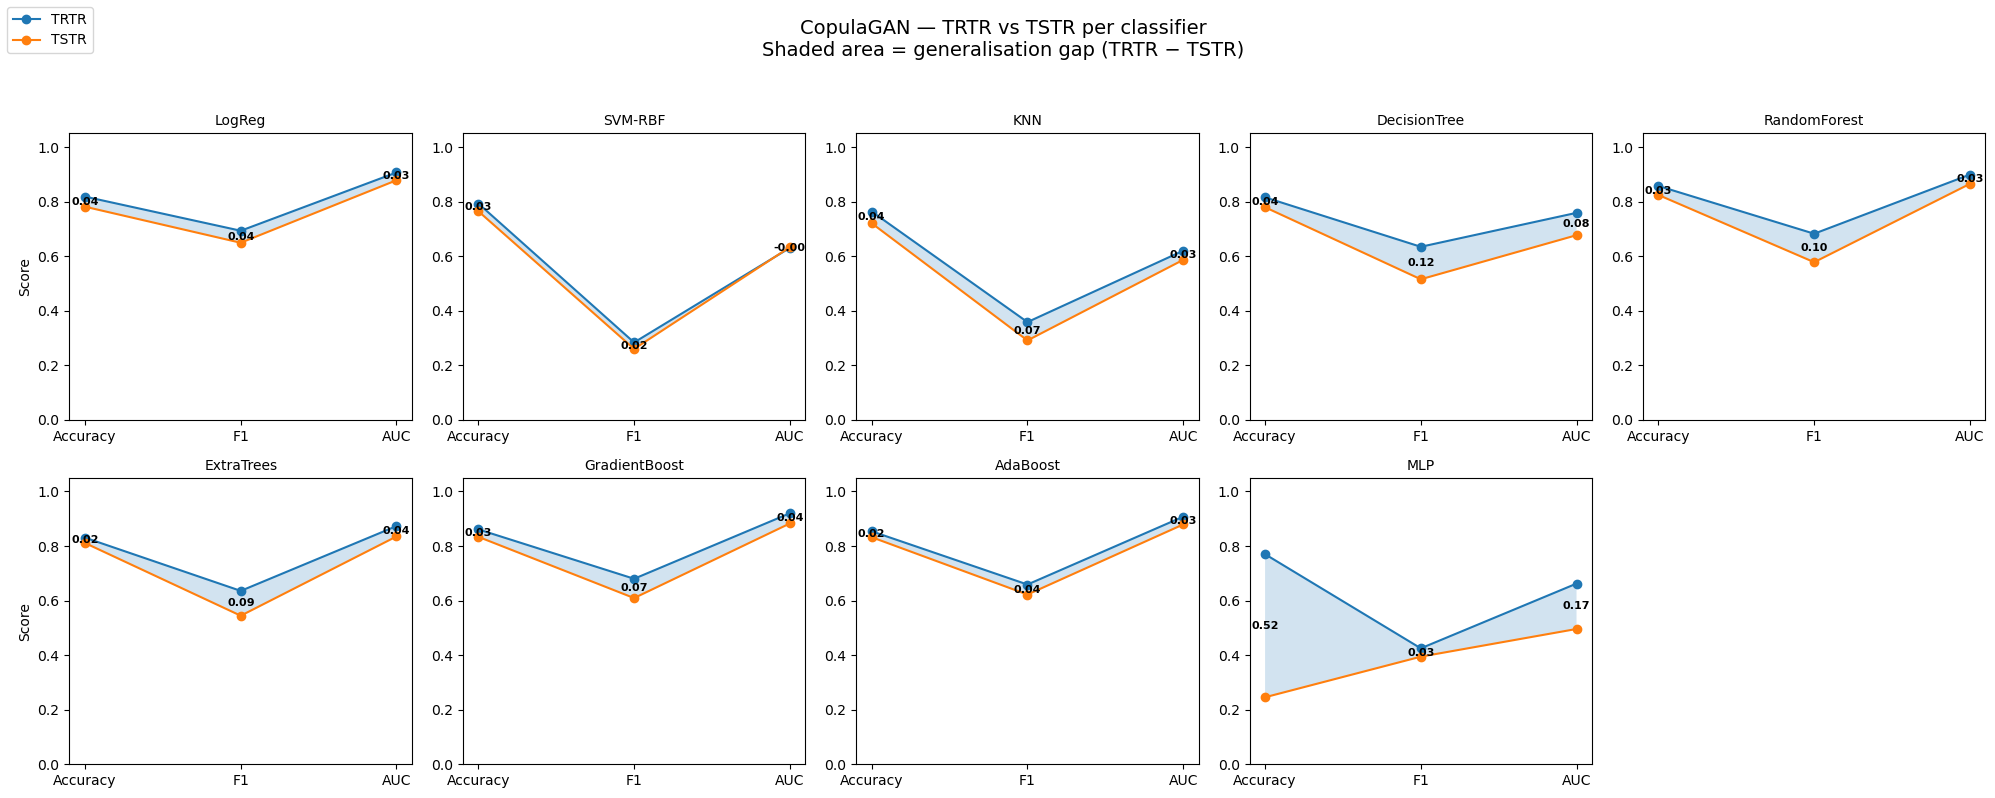

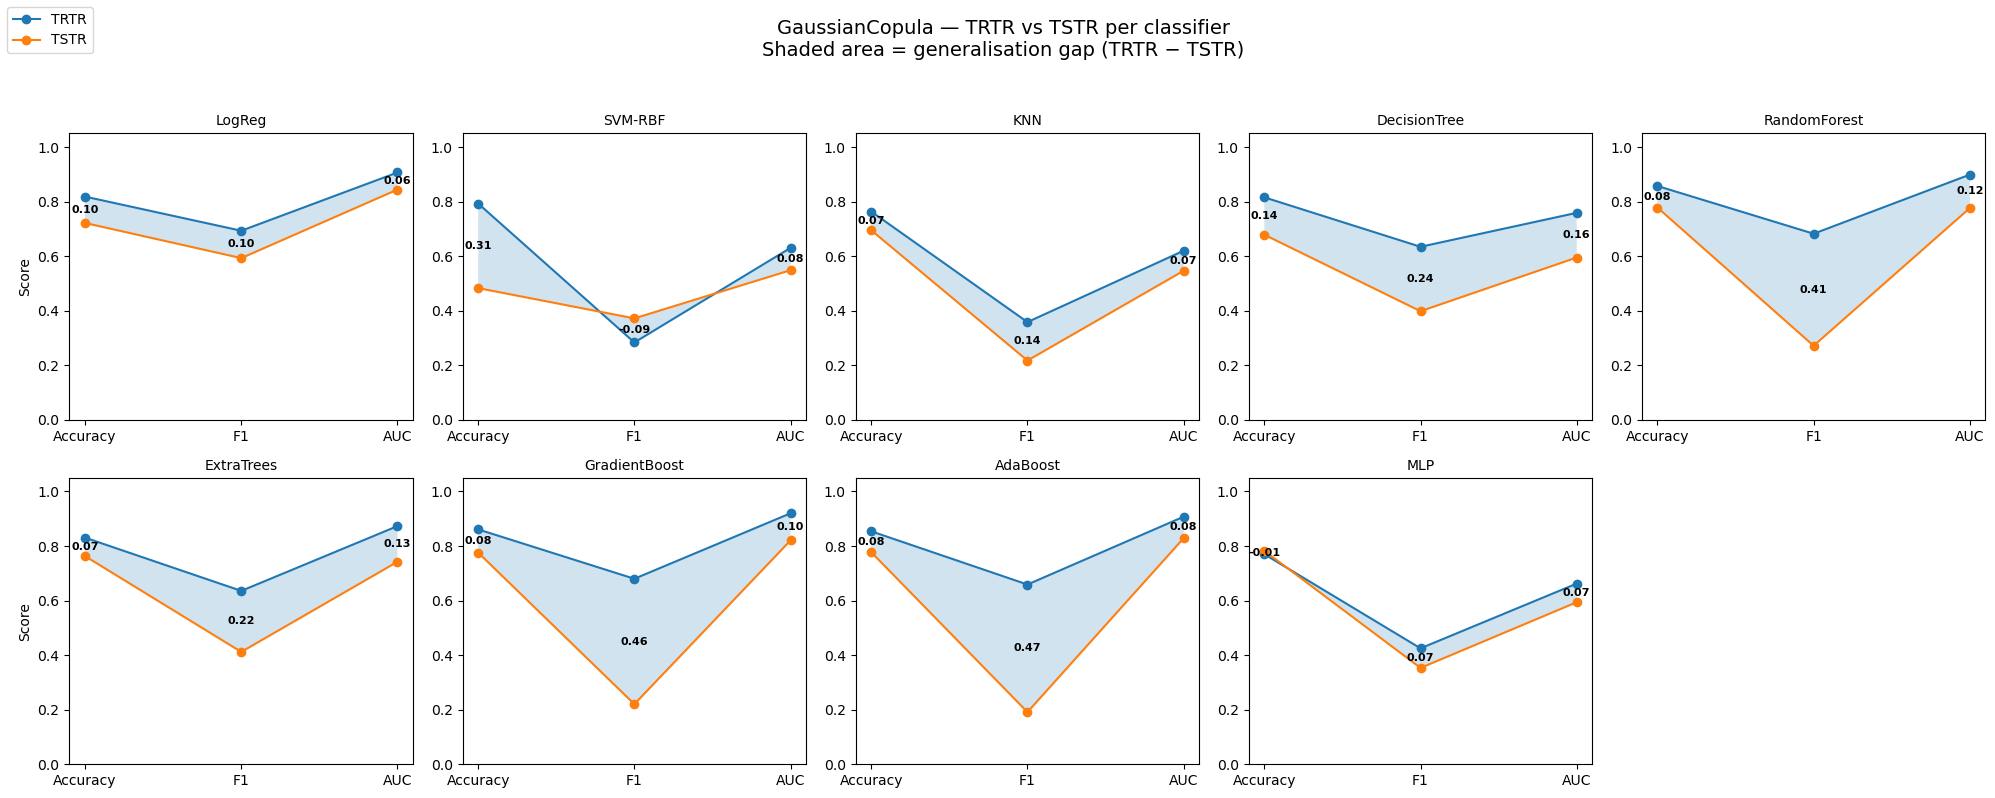

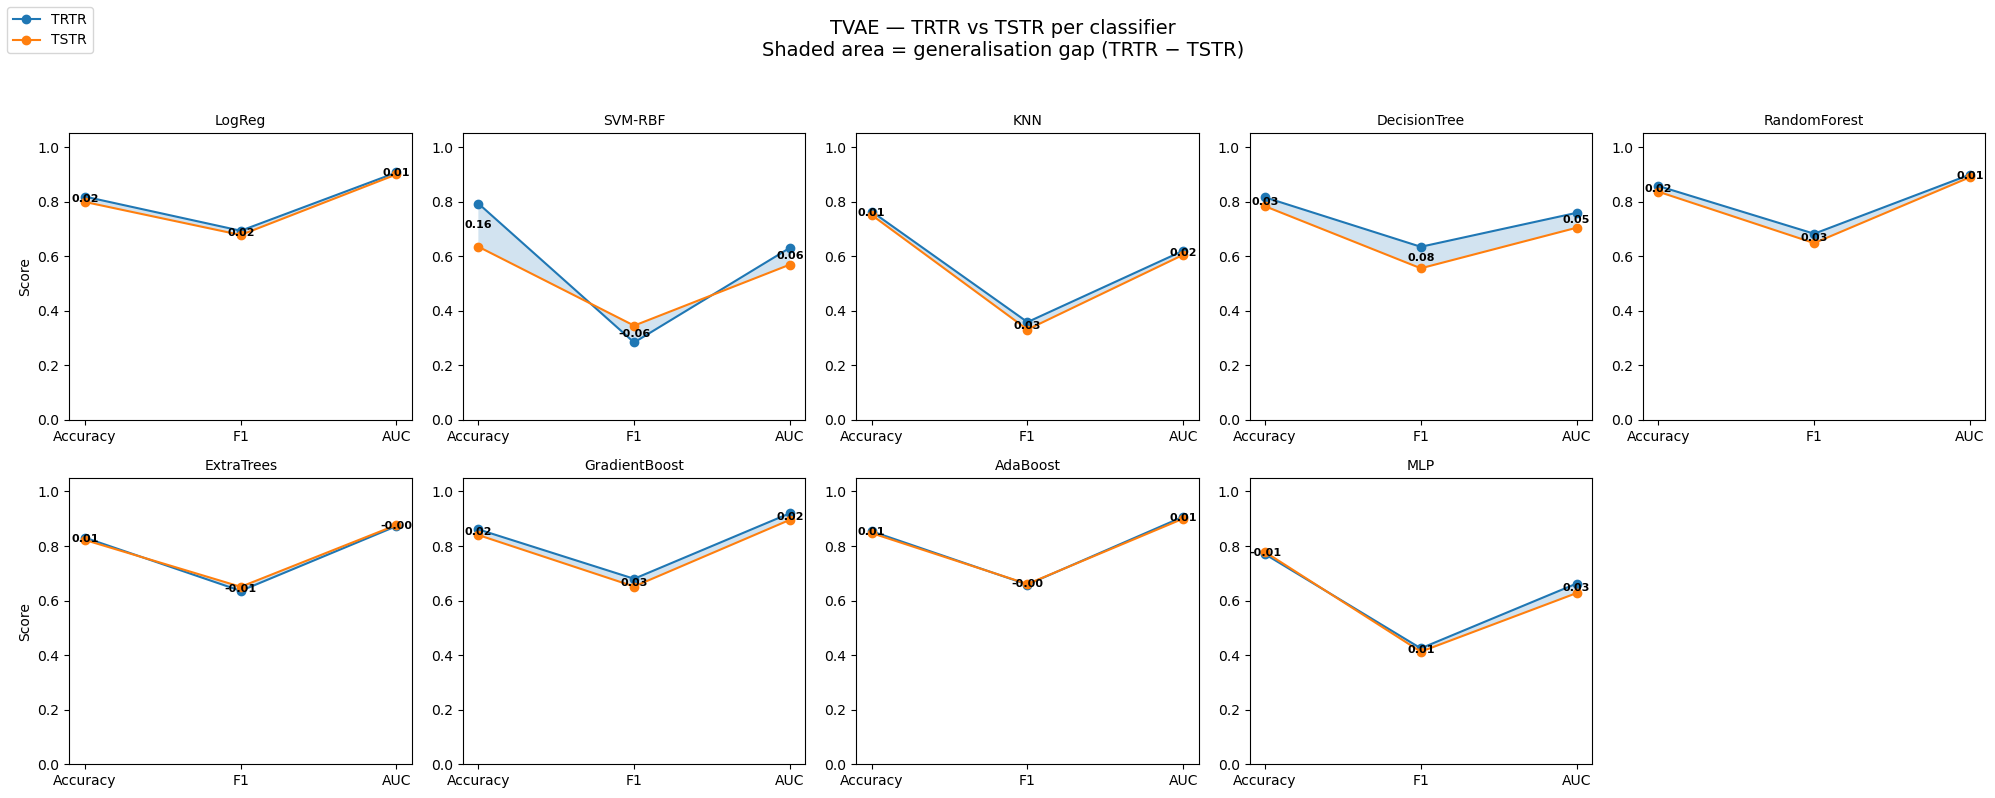

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import math

# --------------------------------------------------
# Extract Synth + Classifier
# --------------------------------------------------
results_df['Synth'] = results_df['Model'].str.extract(r'\((.*?)\)')
results_df['Classifier'] = results_df['Model'].str.extract(r'^(.*?)\s*\(')

synth_list = ['CTGAN', 'CopulaGAN', 'GaussianCopula', 'TVAE']
metrics = ['Accuracy', 'F1', 'AUC']

# --------------------------------------------------
# Plot per synthesizer
# --------------------------------------------------
for synth in synth_list:
    
    df_synth = results_df[results_df['Synth'] == synth].reset_index(drop=True)
    
    n_models = len(df_synth)
    cols = 5
    rows = math.ceil(n_models / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 8))
    axes = axes.flatten()
    
    for i, row in df_synth.iterrows():
        
        ax = axes[i]
        
        trtr = [row[f"{m}_TRTR"] for m in metrics]
        tstr = [row[f"{m}_TSTR"] for m in metrics]
        
        x = np.arange(len(metrics))
        
        # Lines
        ax.plot(x, trtr, marker='o', label='TRTR')
        ax.plot(x, tstr, marker='o', label='TSTR')
        
        # Shaded gap
        ax.fill_between(x, trtr, tstr, alpha=0.2)
        
        # --------------------------------------------------
        # Add difference labels
        # --------------------------------------------------
        for j in range(len(metrics)):
            diff = trtr[j] - tstr[j]
            mid_y = (trtr[j] + tstr[j]) / 2
            
            ax.text(
                x[j], mid_y,
                f"{diff:.2f}",
                ha='center',
                va='center',
                fontsize=8,
                fontweight='bold'
            )
        
        # Titles and labels
        ax.set_title(row['Classifier'], fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        ax.set_ylim(0, 1.05)
        
        if i % cols == 0:
            ax.set_ylabel("Score")
    
    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    # Title
    fig.suptitle(
        f"{synth} — TRTR vs TSTR per classifier\nShaded area = generalisation gap (TRTR − TSTR)",
        fontsize=14
    )
    
    # Legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper left')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## 8. Fidelity: Column Shapes (KS Complement)


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 287.24it/s]|
Column Shapes Score: 89.71%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 245.73it/s]|
Column Pair Trends Score: 85.59%

Overall Score (Average): 87.65%



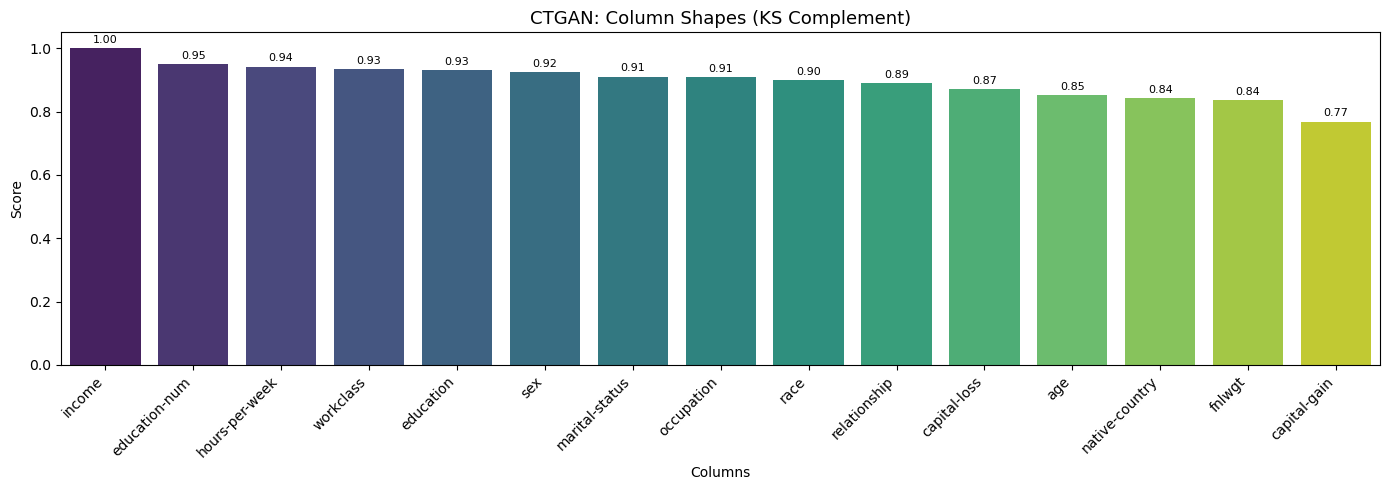

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 340.09it/s]|
Column Shapes Score: 93.0%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 201.21it/s]|
Column Pair Trends Score: 82.4%

Overall Score (Average): 87.7%



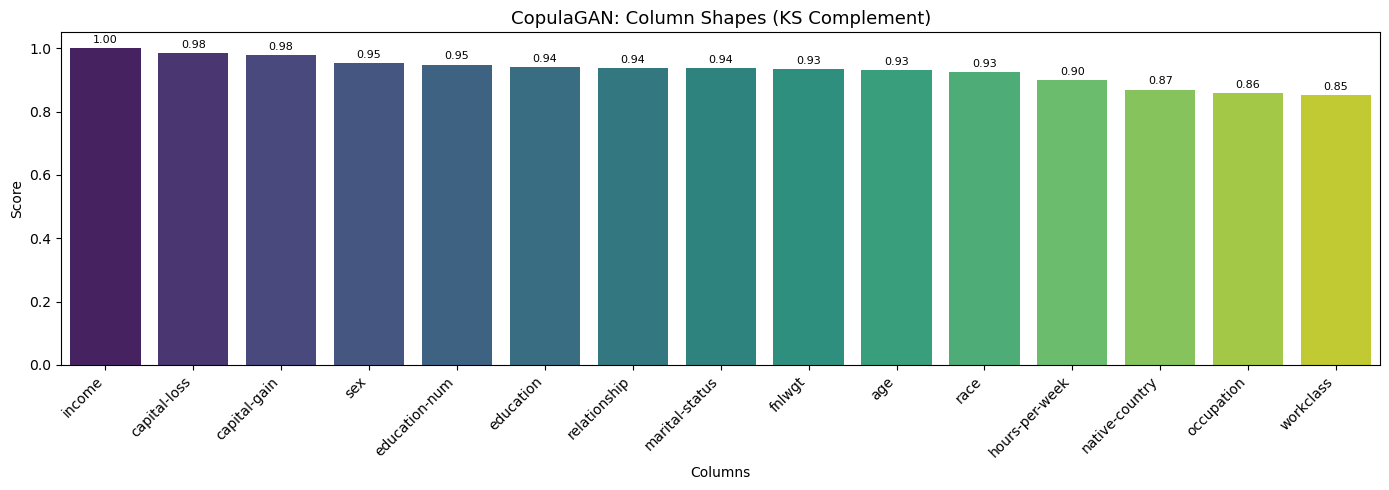

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 290.01it/s]|
Column Shapes Score: 89.84%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 173.32it/s]|
Column Pair Trends Score: 76.09%

Overall Score (Average): 82.96%



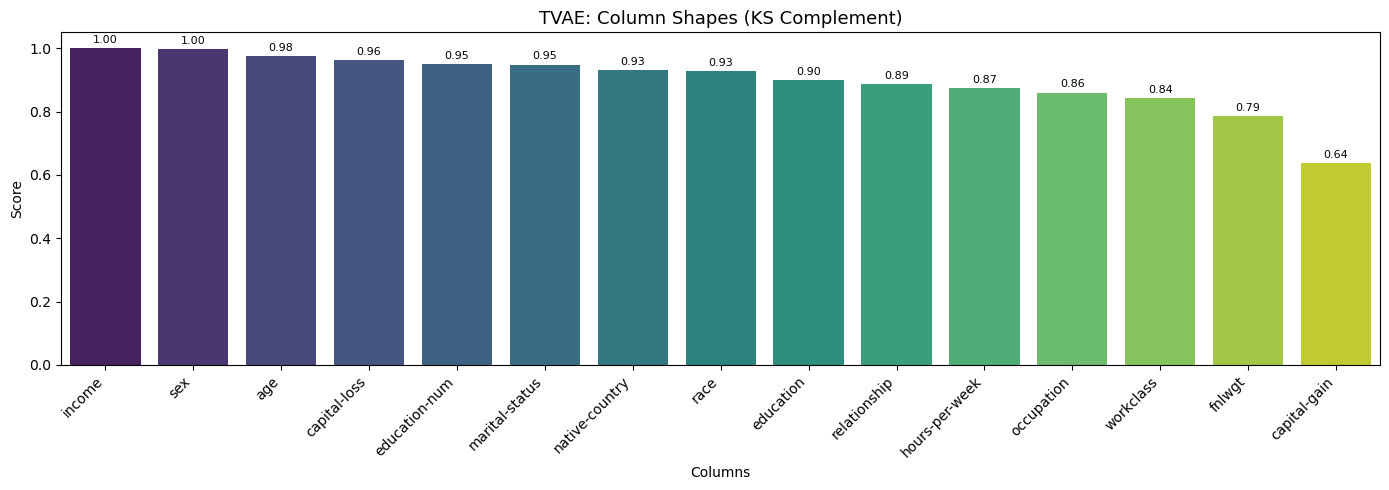

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 267.07it/s]|
Column Shapes Score: 92.58%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 193.34it/s]|
Column Pair Trends Score: 84.98%

Overall Score (Average): 88.78%



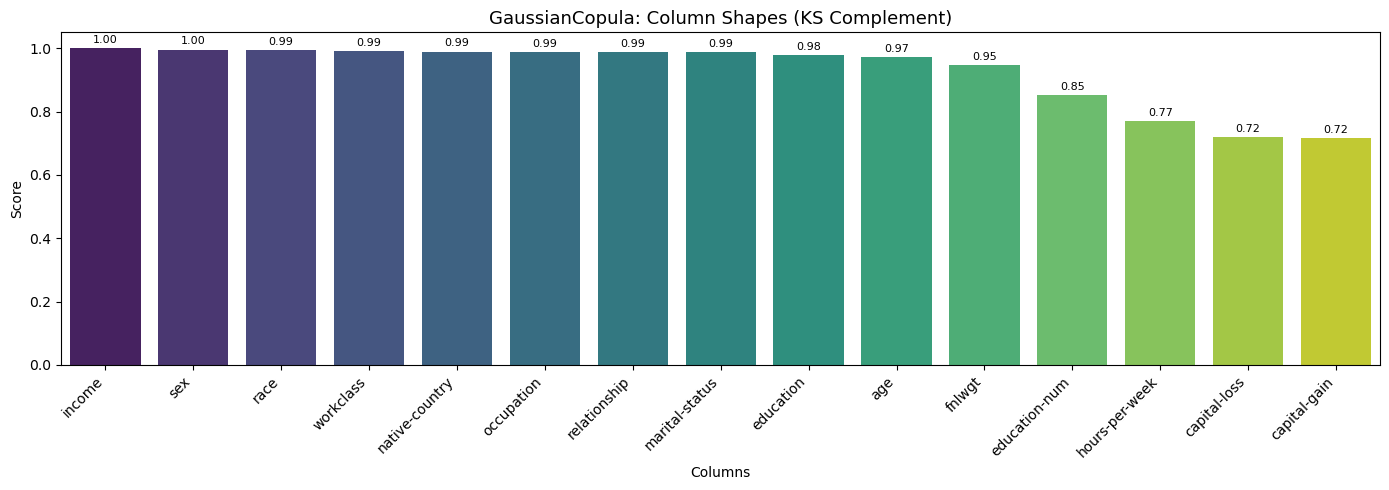

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sdv.evaluation.single_table import QualityReport

# --------------------------------------------------
# Plot Column Shapes (KS Complement)
# --------------------------------------------------
for sdv_name, synth_df in synthetic_data.items():
    
    try:
        # Generate report
        qr = QualityReport()
        qr.generate(
            real_data=adult_sample,
            synthetic_data=synth_df,
            metadata=metadata.to_dict()
        )
        
        # Get details
        details = qr.get_details('Column Shapes')
        details = details.sort_values('Score', ascending=False)
        
        # --------------------------------------------------
        # Plot
        # --------------------------------------------------
        plt.figure(figsize=(14, 5))
        
        ax = sns.barplot(
            data=details,
            x='Column',
            y='Score',
            hue='Column',          # avoids seaborn warning
            dodge=False,
            legend=False,
            palette='viridis'
        )
        
        # --------------------------------------------------
        # Add value labels
        # --------------------------------------------------
        for p in ax.patches:
            height = p.get_height()
            ax.text(
                p.get_x() + p.get_width() / 2,
                height + 0.01,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=8
            )
        
        # --------------------------------------------------
        # Formatting
        # --------------------------------------------------
        plt.title(f'{sdv_name}: Column Shapes (KS Complement)', fontsize=13)
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('Score')
        plt.xlabel('Columns')
        plt.ylim(0, 1.05)   # consistent scale
        
        plt.tight_layout()
        plt.show()
    
    except Exception as e:
        print(f'{sdv_name} column shapes error: {e}')

## 9. Fidelity: Wasserstein Distance (numeric columns)


In [16]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler

wasserstein_results = {}
num_cols_fid = [c for c in NUMERIC_COLS if c in adult_sample.columns]
scaler_w = StandardScaler().fit(adult_sample[num_cols_fid])
real_scaled_w = pd.DataFrame(scaler_w.transform(adult_sample[num_cols_fid]), columns=num_cols_fid)

for sdv_name, synth_df in synthetic_data.items():
    cols = [c for c in num_cols_fid if c in synth_df.columns]
    synth_scaled = pd.DataFrame(scaler_w.transform(synth_df[cols]), columns=cols)
    rows = []
    for col in cols:
        try:
            w = wasserstein_distance(real_scaled_w[col].dropna(), synth_scaled[col].dropna())
        except Exception:
            w = np.nan
        rows.append({'Column': col, 'Wasserstein': w})
    wasserstein_results[sdv_name] = pd.DataFrame(rows).sort_values('Wasserstein')
    print(f'\nWasserstein distances — {sdv_name}:')
    display(wasserstein_results[sdv_name].round(4))


Wasserstein distances — CTGAN:


,Column,Wasserstein
6,income,0.0000
3,capital-gain,0.0552
4,capital-loss,0.0952
5,hours-per-week,0.1061
2,education-num,0.1089
1,fnlwgt,0.2556
0,age,0.2739



Wasserstein distances — CopulaGAN:


,Column,Wasserstein
6,income,0.0000
3,capital-gain,0.0704
4,capital-loss,0.0733
1,fnlwgt,0.0969
2,education-num,0.1086
5,hours-per-week,0.1641
0,age,0.1686



Wasserstein distances — TVAE:


,Column,Wasserstein
6,income,0.0000
4,capital-loss,0.0382
3,capital-gain,0.0394
0,age,0.0490
2,education-num,0.0640
5,hours-per-week,0.2178
1,fnlwgt,0.3662



Wasserstein distances — GaussianCopula:


,Column,Wasserstein
6,income,0.0000
0,age,0.0499
1,fnlwgt,0.0726
3,capital-gain,0.1304
4,capital-loss,0.1337
2,education-num,0.1983
5,hours-per-week,0.2963


## 10. Fidelity: JS Divergence (numeric columns)


In [17]:
from scipy.spatial.distance import jensenshannon

def compute_js_divergence(real_vals, synth_vals, bins=30):
    r = np.asarray(real_vals, dtype=float)
    s = np.asarray(synth_vals, dtype=float)
    r = r[~np.isnan(r)]
    s = s[~np.isnan(s)]
    if len(r) == 0 or len(s) == 0:
        return np.nan
    lo, hi = min(r.min(), s.min()), max(r.max(), s.max())
    if lo == hi:
        return 0.0
    p_hist, edges = np.histogram(r, bins=bins, range=(lo, hi), density=True)
    q_hist, _    = np.histogram(s, bins=edges, density=True)
    p = (p_hist + 1e-12); p /= p.sum()
    q = (q_hist + 1e-12); q /= q.sum()
    return float(jensenshannon(p, q, base=2) ** 2)

js_results = {}
scaler_js = StandardScaler().fit(adult_sample[num_cols_fid])
real_scaled_js = pd.DataFrame(scaler_js.transform(adult_sample[num_cols_fid]), columns=num_cols_fid)

for sdv_name, synth_df in synthetic_data.items():
    cols = [c for c in num_cols_fid if c in synth_df.columns]
    synth_scaled = pd.DataFrame(scaler_js.transform(synth_df[cols]), columns=cols)
    rows = [{'Column': c, 'JS_Divergence': compute_js_divergence(real_scaled_js[c], synth_scaled[c])} for c in cols]
    js_results[sdv_name] = pd.DataFrame(rows).sort_values('JS_Divergence')
    print(f'\nJS Divergence — {sdv_name}:')
    display(js_results[sdv_name].round(4))


JS Divergence — CTGAN:


,Column,JS_Divergence
6,income,0.0000
3,capital-gain,0.0071
4,capital-loss,0.0096
2,education-num,0.0108
1,fnlwgt,0.0221
0,age,0.0232
5,hours-per-week,0.0800



JS Divergence — CopulaGAN:


,Column,JS_Divergence
6,income,0.0000
4,capital-loss,0.0053
1,fnlwgt,0.0128
2,education-num,0.0147
0,age,0.0181
3,capital-gain,0.0186
5,hours-per-week,0.1200



JS Divergence — TVAE:


,Column,JS_Divergence
6,income,0.0000
3,capital-gain,0.0029
4,capital-loss,0.0058
0,age,0.0073
2,education-num,0.0152
5,hours-per-week,0.0819
1,fnlwgt,0.0851



JS Divergence — GaussianCopula:


,Column,JS_Divergence
6,income,0.0000
0,age,0.0032
1,fnlwgt,0.0086
3,capital-gain,0.0203
4,capital-loss,0.0479
2,education-num,0.1298
5,hours-per-week,0.1971


## 11. Fidelity: Gower Distance


In [18]:
from sklearn.neighbors import NearestNeighbors

def gower_distance_numeric(real_df, synth_df, num_cols, n_sample=500):
    """Mean nearest-neighbour Gower-like (L1 normalised by range) distance."""
    r = real_df[num_cols].dropna().sample(min(n_sample, len(real_df)), random_state=42)
    s = synth_df[num_cols].dropna().sample(min(n_sample, len(synth_df)), random_state=42)
    rng = (r.max() - r.min()).replace(0, 1)
    r_n = (r - r.min()) / rng
    s_n = (s - r.min()) / rng  # scale synth by real range
    nn = NearestNeighbors(n_neighbors=1, metric='manhattan').fit(s_n)
    dists, _ = nn.kneighbors(r_n)
    return float(np.mean(dists))

gower_results = {}
for sdv_name, synth_df in synthetic_data.items():
    cols = [c for c in num_cols_fid if c in synth_df.columns]
    gower_results[sdv_name] = gower_distance_numeric(adult_sample, synth_df, cols)
    print(f'{sdv_name}: mean Gower distance = {gower_results[sdv_name]:.4f}')

print('\nGower (lower = better):', gower_results)

CTGAN: mean Gower distance = 0.1640
CopulaGAN: mean Gower distance = 0.1662
TVAE: mean Gower distance = 0.1720
GaussianCopula: mean Gower distance = 0.2032

Gower (lower = better): {'CTGAN': 0.16399762176287438, 'CopulaGAN': 0.16624103923428787, 'TVAE': 0.1720064871320916, 'GaussianCopula': 0.2031892757235005}


## 12. Fidelity: MMD (Maximum Mean Discrepancy)


In [19]:
def mmd_rbf(real, synth, gamma=None, n_sample=500):
    """Maximum Mean Discrepancy with RBF kernel. Lower is better."""
    real  = np.asarray(real)[:n_sample]
    synth = np.asarray(synth)[:n_sample]
    if real.ndim == 1:
        real = real.reshape(-1, 1)
    if synth.ndim == 1:
        synth = synth.reshape(-1, 1)
    if gamma is None:
        gamma = 1.0 / max(real.shape[1], 1)
    def rbf(X, Y):
        dxx = np.sum(X**2, axis=1, keepdims=True) + np.sum(Y**2, axis=1) - 2 * X @ Y.T
        return np.exp(-gamma * np.maximum(dxx, 0))
    return float(max(0, np.mean(rbf(real, real)) + np.mean(rbf(synth, synth)) - 2 * np.mean(rbf(real, synth))) ** 0.5)

mmd_results = {}
scaler_mmd = StandardScaler().fit(adult_sample[num_cols_fid])
real_scaled_mmd = scaler_mmd.transform(adult_sample[num_cols_fid])

for sdv_name, synth_df in synthetic_data.items():
    cols = [c for c in num_cols_fid if c in synth_df.columns]
    synth_scaled = scaler_mmd.transform(synth_df[cols])
    mmd_results[sdv_name] = mmd_rbf(real_scaled_mmd, synth_scaled)
    print(f'{sdv_name}: MMD = {mmd_results[sdv_name]:.4f}')

print('\nMMD (lower = better):', mmd_results)

CTGAN: MMD = 0.2000
CopulaGAN: MMD = 0.1916
TVAE: MMD = 0.1917
GaussianCopula: MMD = 0.1692

MMD (lower = better): {'CTGAN': 0.20000833221297806, 'CopulaGAN': 0.1915732687518634, 'TVAE': 0.1917003619550956, 'GaussianCopula': 0.169235761822064}


## 13. Fidelity: Cosine Similarity of Correlation Matrices


In [20]:
from numpy.linalg import norm

def correlation_cosine_similarity(real_df, synth_df, num_cols):
    r_corr = real_df[num_cols].corr().values
    s_corr = synth_df[num_cols].corr().values
    idx = np.triu_indices(len(num_cols), k=1)
    r_flat, s_flat = r_corr[idx], s_corr[idx]
    if norm(r_flat) < 1e-12 or norm(s_flat) < 1e-12:
        return float('nan')
    return float(np.dot(r_flat, s_flat) / (norm(r_flat) * norm(s_flat)))

cosine_results = {}
for sdv_name, synth_df in synthetic_data.items():
    cols = [c for c in num_cols_fid if c in synth_df.columns]
    cosine_results[sdv_name] = correlation_cosine_similarity(adult_sample, synth_df, cols)
    print(f'{sdv_name}: correlation cosine similarity = {cosine_results[sdv_name]:.4f}')

print('\nCosine similarity of correlation matrices (higher = better):', cosine_results)

CTGAN: correlation cosine similarity = 0.9427
CopulaGAN: correlation cosine similarity = 0.9541
TVAE: correlation cosine similarity = 0.9150
GaussianCopula: correlation cosine similarity = 0.9211

Cosine similarity of correlation matrices (higher = better): {'CTGAN': 0.9427451664831055, 'CopulaGAN': 0.95407307063301, 'TVAE': 0.9150356721775277, 'GaussianCopula': 0.9210663237432255}


## 14. Fidelity: Average Nearest Neighbour Distance


In [21]:
def ann_distance(real_df, synth_df, num_cols, n_sample=500):
    scaler = StandardScaler().fit(real_df[num_cols])
    r = scaler.transform(real_df[num_cols])[:n_sample]
    s = scaler.transform(synth_df[num_cols])[:n_sample]
    nn_s = NearestNeighbors(n_neighbors=1).fit(s)
    nn_r = NearestNeighbors(n_neighbors=1).fit(r)
    d_r2s, _ = nn_s.kneighbors(r)
    d_s2r, _ = nn_r.kneighbors(s)
    return float((np.mean(d_r2s) + np.mean(d_s2r)) / 2), float(np.mean(d_r2s)), float(np.mean(d_s2r))

ann_results = {}
for sdv_name, synth_df in synthetic_data.items():
    cols = [c for c in num_cols_fid if c in synth_df.columns]
    sym, r2s, s2r = ann_distance(adult_sample, synth_df, cols)
    ann_results[sdv_name] = sym
    print(f'{sdv_name}: ANN symmetric={sym:.4f}  (real→synth={r2s:.4f}, synth→real={s2r:.4f})')

print('\nANN distance (lower = better):', ann_results)

CTGAN: ANN symmetric=0.7687  (real→synth=0.6175, synth→real=0.9199)
CopulaGAN: ANN symmetric=0.8336  (real→synth=0.5887, synth→real=1.0785)
TVAE: ANN symmetric=0.8152  (real→synth=0.6978, synth→real=0.9326)
GaussianCopula: ANN symmetric=0.8869  (real→synth=0.6632, synth→real=1.1105)

ANN distance (lower = better): {'CTGAN': 0.7687101941680649, 'CopulaGAN': 0.8335923239078822, 'TVAE': 0.8151850100967988, 'GaussianCopula': 0.8868844413082358}


## 15. Fidelity Summary Table


In [22]:
fidelity_summary = pd.DataFrame({
    'Model': list(synthetic_data.keys()),
    'MMD (↓)': [mmd_results.get(k, np.nan) for k in synthetic_data],
    'Gower (↓)': [gower_results.get(k, np.nan) for k in synthetic_data],
    'ANN_dist (↓)': [ann_results.get(k, np.nan) for k in synthetic_data],
    'Corr_Cosine (↑)': [cosine_results.get(k, np.nan) for k in synthetic_data],
    'Avg_Wasserstein (↓)': [
        wasserstein_results[k]['Wasserstein'].mean() if k in wasserstein_results else np.nan
        for k in synthetic_data
    ],
    'Avg_JS (↓)': [
        js_results[k]['JS_Divergence'].mean() if k in js_results else np.nan
        for k in synthetic_data
    ],
})

print('\nFidelity Summary (↓=lower is better, ↑=higher is better)')
display(fidelity_summary.set_index('Model').round(4))


Fidelity Summary (↓=lower is better, ↑=higher is better)


,MMD (↓),Gower (↓),ANN_dist (↓),Corr_Cosine (↑),Avg_Wasserstein (↓),Avg_JS (↓)
Model,,,,,,
CTGAN,0.2000,0.1640,0.7687,0.9427,0.1278,0.0218
CopulaGAN,0.1916,0.1662,0.8336,0.9541,0.0974,0.0271
TVAE,0.1917,0.1720,0.8152,0.9150,0.1107,0.0283
GaussianCopula,0.1692,0.2032,0.8869,0.9211,0.1259,0.0581


## 16. Bivariate Analysis (Δ-correlation)


In [23]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

def bivariate_quality_adult(real_df, synth_df, target='income'):
    """Δ pairwise correlation (numeric) and Δ feature-target Wasserstein (by income class)."""
    num_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target]
    scaler = MinMaxScaler()
    real_sc = real_df.copy()
    synth_sc = synth_df.copy()
    real_sc[num_cols]  = scaler.fit_transform(real_df[num_cols])
    synth_sc[num_cols] = scaler.transform(synth_df[num_cols])

    # Numeric–numeric: Δ correlation
    corr_rows = []
    for a, b in combinations(num_cols, 2):
        r_c = real_sc[[a, b]].corr().iloc[0, 1]
        s_c = synth_sc[[a, b]].corr().iloc[0, 1]
        corr_rows.append({'var_a': a, 'var_b': b, 'delta_corr': abs(r_c - s_c)})
    corr_df = pd.DataFrame(corr_rows).sort_values('delta_corr', ascending=False)

    # Numeric–target: Δ mean Wasserstein between income classes
    target_rows = []
    for col in num_cols:
        r_grps = [g[col].values for _, g in real_sc.groupby(target)]
        s_grps = [g[col].values for _, g in synth_sc.groupby(target)]
        if len(r_grps) >= 2 and len(s_grps) >= 2:
            r_dists = [stats.wasserstein_distance(r_grps[i], r_grps[j])
                       for i, j in combinations(range(len(r_grps)), 2)]
            s_dists = [stats.wasserstein_distance(s_grps[i], s_grps[j])
                       for i, j in combinations(range(len(s_grps)), 2)]
            d_real  = np.mean(r_dists) if r_dists else 0.0
            d_synth = np.mean(s_dists) if s_dists else 0.0
            target_rows.append({'feature': col, 'delta_wass_target': abs(d_real - d_synth)})
    target_df = pd.DataFrame(target_rows).sort_values('delta_wass_target', ascending=False)
    return corr_df, target_df

bivariate_results = {}
for sdv_name, synth_df in synthetic_data.items():
    corr_df, target_df = bivariate_quality_adult(adult_sample, synth_df, target=label_col)
    bivariate_results[sdv_name] = {'corr_df': corr_df, 'target_df': target_df}
    print(f'\n{sdv_name} — Top 5 Δ-correlation (numeric pairs):')
    display(corr_df.head().round(4))
    print(f'{sdv_name} — Top 5 Δ Wasserstein vs income:')
    display(target_df.head().round(4))


CTGAN — Top 5 Δ-correlation (numeric pairs):


,var_a,var_b,delta_corr
12,capital-gain,capital-loss,0.0877
4,age,hours-per-week,0.0797
0,age,fnlwgt,0.0793
1,age,education-num,0.0486
9,education-num,capital-gain,0.0435


CTGAN — Top 5 Δ Wasserstein vs income:


,feature,delta_wass_target
3,capital-gain,0.0204
0,age,0.0160
4,capital-loss,0.0138
5,hours-per-week,0.0128
2,education-num,0.0074



CopulaGAN — Top 5 Δ-correlation (numeric pairs):


...

,feature,delta_wass_target
0,age,0.0364
2,education-num,0.0339
4,capital-loss,0.0146
3,capital-gain,0.0111
5,hours-per-week,0.0074



GaussianCopula — Top 5 Δ-correlation (numeric pairs):


,var_a,var_b,delta_corr
4,age,hours-per-week,0.0648
9,education-num,capital-gain,0.0614
10,education-num,capital-loss,0.0418
0,age,fnlwgt,0.0360
13,capital-gain,hours-per-week,0.0350


GaussianCopula — Top 5 Δ Wasserstein vs income:


,feature,delta_wass_target
2,education-num,0.0656
3,capital-gain,0.0392
0,age,0.0392
5,hours-per-week,0.0315
4,capital-loss,0.0242


## 17. t-SNE Visualisation (Real vs Synthetic)


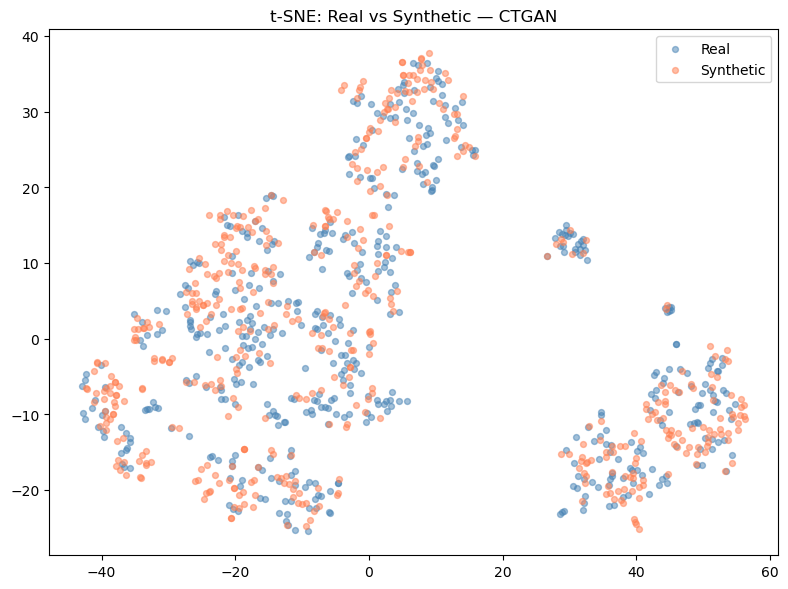

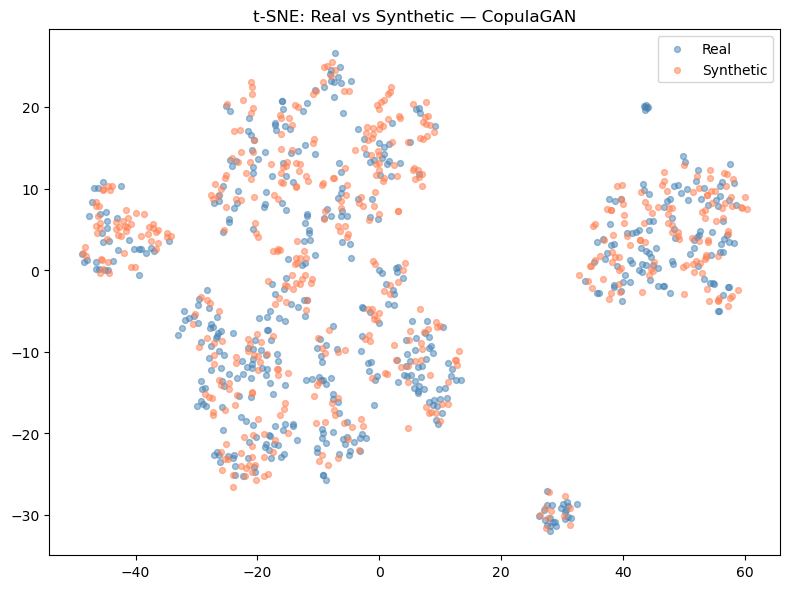

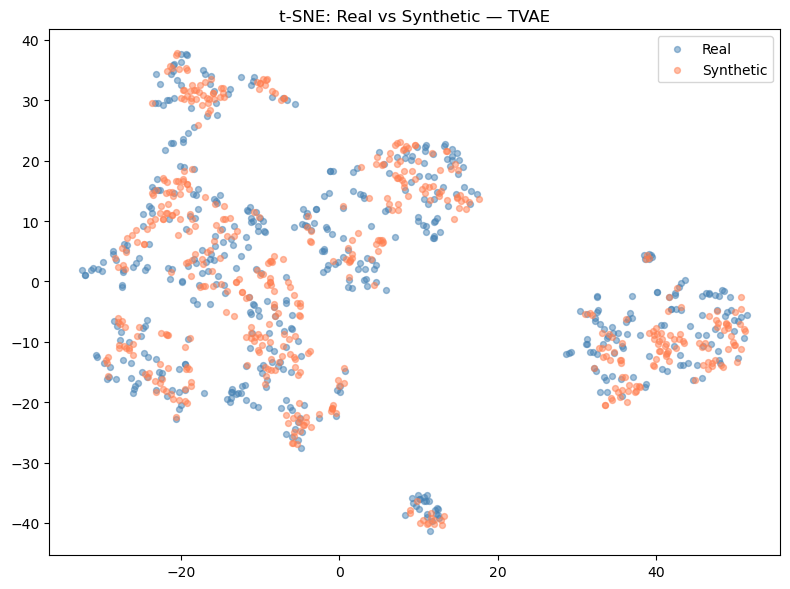

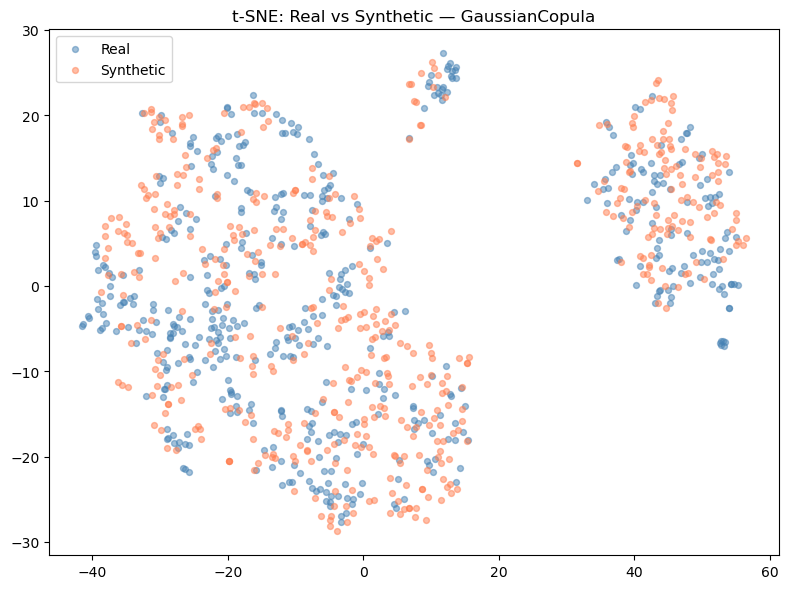

In [24]:
from sklearn.manifold import TSNE

scaler_tsne = StandardScaler().fit(adult_sample[num_cols_fid])

for sdv_name, synth_df in synthetic_data.items():
    cols = [c for c in num_cols_fid if c in synth_df.columns]
    r_sc = scaler_tsne.transform(adult_sample[cols])
    s_sc = scaler_tsne.transform(synth_df[cols])
    n_r = min(500, len(r_sc))
    n_s = min(500, len(s_sc))
    rng = np.random.default_rng(42)
    r_samp = r_sc[rng.choice(len(r_sc), n_r, replace=False)]
    s_samp = s_sc[rng.choice(len(s_sc), n_s, replace=False)]
    combined = np.vstack([r_samp, s_samp])
    X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(combined)
    plt.figure(figsize=(8, 6))
    plt.scatter(X_tsne[:n_r, 0], X_tsne[:n_r, 1], c='steelblue', alpha=0.5, s=18, label='Real')
    plt.scatter(X_tsne[n_r:, 0], X_tsne[n_r:, 1], c='coral', alpha=0.5, s=18, label='Synthetic')
    plt.title(f't-SNE: Real vs Synthetic — {sdv_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 18. Cosine Similarity: Greedy and Hungarian Matching


In [25]:
from scipy.optimize import linear_sum_assignment

def _normalize_rows(X):
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

scaler_cos = StandardScaler().fit(adult_sample[num_cols_fid])
_real_mat = _normalize_rows(scaler_cos.transform(adult_sample[num_cols_fid]))

greedy_results   = {}
hungarian_results = {}

for sdv_name, synth_df in synthetic_data.items():
    cols = [c for c in num_cols_fid if c in synth_df.columns]
    _synth_mat = _normalize_rows(scaler_cos.transform(synth_df[cols]))
    n = min(len(_real_mat), len(_synth_mat))
    cos_mat = _real_mat[:n] @ _synth_mat[:n].T  # (n_real x n_synth)

    # Greedy
    best_idx = np.argmax(cos_mat, axis=1)
    best_sim = cos_mat[np.arange(n), best_idx]
    greedy_results[sdv_name] = float(np.mean(best_sim))

    # Hungarian (1-to-1 optimal matching)
    row_ind, col_ind = linear_sum_assignment(1.0 - cos_mat)
    hung_sim = cos_mat[row_ind, col_ind]
    hungarian_results[sdv_name] = {
        'avg_similarity': float(np.mean(hung_sim)),
        'row_ind': row_ind, 'col_ind': col_ind, 'similarities': hung_sim
    }
    print(f'{sdv_name}: greedy avg={greedy_results[sdv_name]:.4f}  Hungarian avg={hungarian_results[sdv_name]["avg_similarity"]:.4f}')

summary_cos = pd.DataFrame({
    'Model': list(greedy_results.keys()),
    'Greedy_avg_cosine': list(greedy_results.values()),
    'Hungarian_avg_cosine': [hungarian_results[k]['avg_similarity'] for k in greedy_results],
})
display(summary_cos.round(4))

CTGAN: greedy avg=0.9908  Hungarian avg=0.9452
CopulaGAN: greedy avg=0.9918  Hungarian avg=0.9642
TVAE: greedy avg=0.9834  Hungarian avg=0.9385
GaussianCopula: greedy avg=0.9854  Hungarian avg=0.9446


,Model,Greedy_avg_cosine,Hungarian_avg_cosine
0,CTGAN,0.9908,0.9452
1,CopulaGAN,0.9918,0.9642
2,TVAE,0.9834,0.9385
3,GaussianCopula,0.9854,0.9446


## 19. Privacy Check: Remaining Synthetic Samples (Cosine + Hungarian)


In [26]:
PRIVACY_THRESHOLD = 0.95

for sdv_name, synth_df in synthetic_data.items():
    cols = [c for c in num_cols_fid if c in synth_df.columns]
    _synth_mat = _normalize_rows(scaler_cos.transform(synth_df[cols]))
    n_real  = len(_real_mat)
    n_synth = len(_synth_mat)
    n = min(n_real, n_synth)
    cos_mat = _real_mat[:n] @ _synth_mat[:n].T

    row_ind, col_ind = linear_sum_assignment(1.0 - cos_mat)
    matched = set(col_ind.tolist())
    remaining = sorted(set(range(n)) - matched)

    too_close = {j: float(cos_mat[:, j].max()) for j in remaining
                 if cos_mat[:, j].max() >= PRIVACY_THRESHOLD}

    print(f'\n{sdv_name}: matched={len(col_ind)}  remaining={len(remaining)}  too-close (>= {PRIVACY_THRESHOLD})={len(too_close)}')
    if too_close:
        for j, sim in sorted(too_close.items(), key=lambda x: -x[1])[:5]:
            print(f'  S{j+1} max cosine = {sim:.4f}')


CTGAN: matched=10000  remaining=0  too-close (>= 0.95)=0

CopulaGAN: matched=10000  remaining=0  too-close (>= 0.95)=0

TVAE: matched=10000  remaining=0  too-close (>= 0.95)=0

GaussianCopula: matched=10000  remaining=0  too-close (>= 0.95)=0


## 20. Mahalanobis Distance + Hungarian Matching


In [27]:
from numpy.linalg import inv, LinAlgError
from scipy.spatial.distance import cdist

def fit_mahalanobis(real_matrix, reg=1e-6):
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        return inv(cov + reg * np.eye(p))
    except LinAlgError:
        return inv(cov + (reg * 10) * np.eye(p))

scaler_mah = StandardScaler().fit(adult_sample[num_cols_fid])
_real_mat_mah = scaler_mah.transform(adult_sample[num_cols_fid])
_inv_cov_mah  = fit_mahalanobis(_real_mat_mah)

mahal_results = {}
for sdv_name, synth_df in synthetic_data.items():
    cols = [c for c in num_cols_fid if c in synth_df.columns]
    _synth_mat_mah = scaler_mah.transform(synth_df[cols])
    n = min(len(_real_mat_mah), len(_synth_mat_mah))
    D = cdist(_real_mat_mah[:n], _synth_mat_mah[:n], metric='mahalanobis', VI=_inv_cov_mah)
    row_ind, col_ind = linear_sum_assignment(D)
    matched_d = D[row_ind, col_ind]
    mahal_results[sdv_name] = {'mean': float(matched_d.mean()), 'median': float(np.median(matched_d))}
    print(f'{sdv_name}: mean Mahalanobis = {matched_d.mean():.4f}  median = {np.median(matched_d):.4f}')

display(pd.DataFrame([
    {'Model': k, 'Mean_Mahalanobis': v['mean'], 'Median_Mahalanobis': v['median']}
    for k, v in mahal_results.items()
]).round(4))

CTGAN: mean Mahalanobis = 0.7210  median = 0.4831
CopulaGAN: mean Mahalanobis = 0.6761  median = 0.4507
TVAE: mean Mahalanobis = 0.7321  median = 0.5035
GaussianCopula: mean Mahalanobis = 0.8326  median = 0.5951


,Model,Mean_Mahalanobis,Median_Mahalanobis
0,CTGAN,0.7210,0.4831
1,CopulaGAN,0.6761,0.4507
2,TVAE,0.7321,0.5035
3,GaussianCopula,0.8326,0.5951


## 21. PCA + Clustering (GaussianCopula)


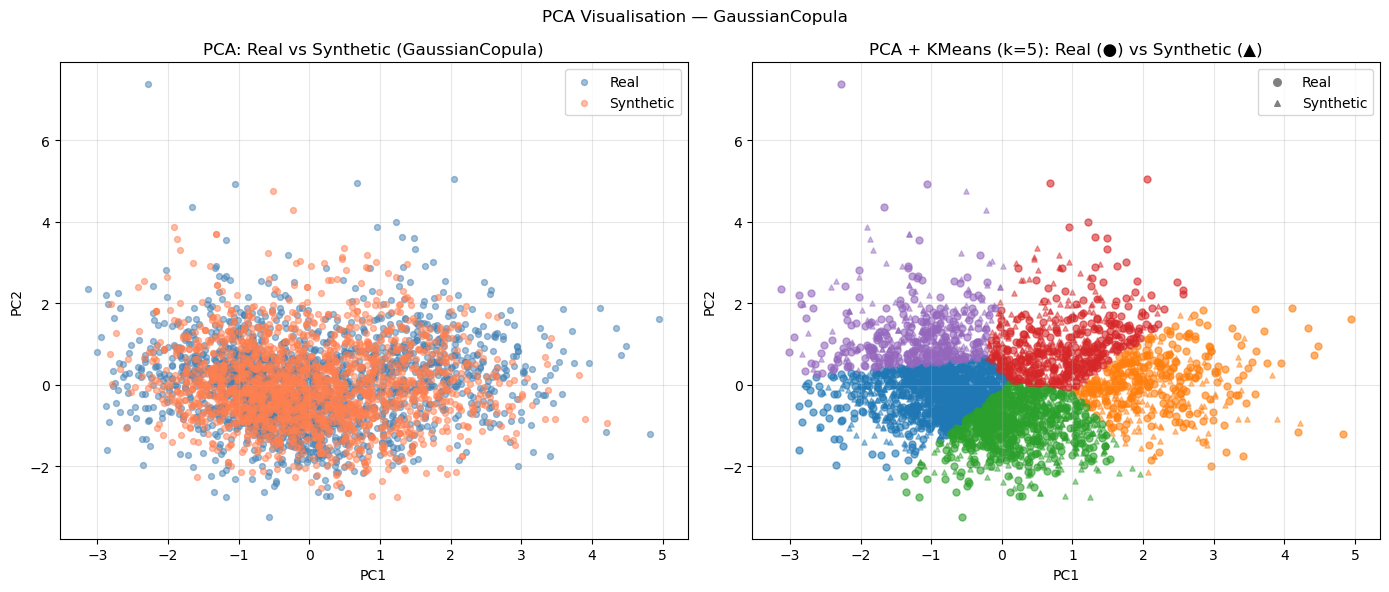

PCA explained variance: [0.237 0.162]


In [28]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

model_name = 'GaussianCopula'
if model_name not in synthetic_data:
    model_name = list(synthetic_data.keys())[0]  # fallback

synth_df = synthetic_data[model_name]
cols = [c for c in num_cols_fid if c in synth_df.columns]

n_sample = 2000
rng = np.random.default_rng(42)
n_r = min(n_sample, len(adult_sample))
n_s = min(n_sample, len(synth_df))
r_idx = rng.choice(len(adult_sample), n_r, replace=False)
s_idx = rng.choice(len(synth_df), n_s, replace=False)

scaler_pca = StandardScaler().fit(adult_sample[cols])
X_r = scaler_pca.transform(adult_sample.iloc[r_idx][cols])
X_s = scaler_pca.transform(synth_df.iloc[s_idx][cols])
combined = np.vstack([X_r, X_s])

pca = PCA(n_components=2, random_state=42).fit(combined)
Z = pca.transform(combined)
Z_r, Z_s = Z[:n_r], Z[n_r:]

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(Z)
lbl_r = kmeans.predict(Z_r)
lbl_s = kmeans.predict(Z_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(Z_r[:, 0], Z_r[:, 1], c='steelblue', alpha=0.5, s=18, label='Real')
ax.scatter(Z_s[:, 0], Z_s[:, 1], c='coral',     alpha=0.5, s=18, label='Synthetic')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'PCA: Real vs Synthetic ({model_name})')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
for k in range(n_clusters):
    mr, ms = lbl_r == k, lbl_s == k
    if mr.any(): ax.scatter(Z_r[mr, 0], Z_r[mr, 1], c=f'C{k}', alpha=0.6, s=25, marker='o')
    if ms.any(): ax.scatter(Z_s[ms, 0], Z_s[ms, 1], c=f'C{k}', alpha=0.45, s=14, marker='^')
ax.scatter([], [], c='gray', s=30, marker='o', label='Real')
ax.scatter([], [], c='gray', s=16, marker='^', label='Synthetic')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'PCA + KMeans (k={n_clusters}): Real (●) vs Synthetic (▲)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'PCA Visualisation — {model_name}', fontsize=12)
plt.tight_layout()
plt.show()
print(f'PCA explained variance: {pca.explained_variance_ratio_.round(3)}')

## 22. PCA + Mahalanobis Distance Heatmap


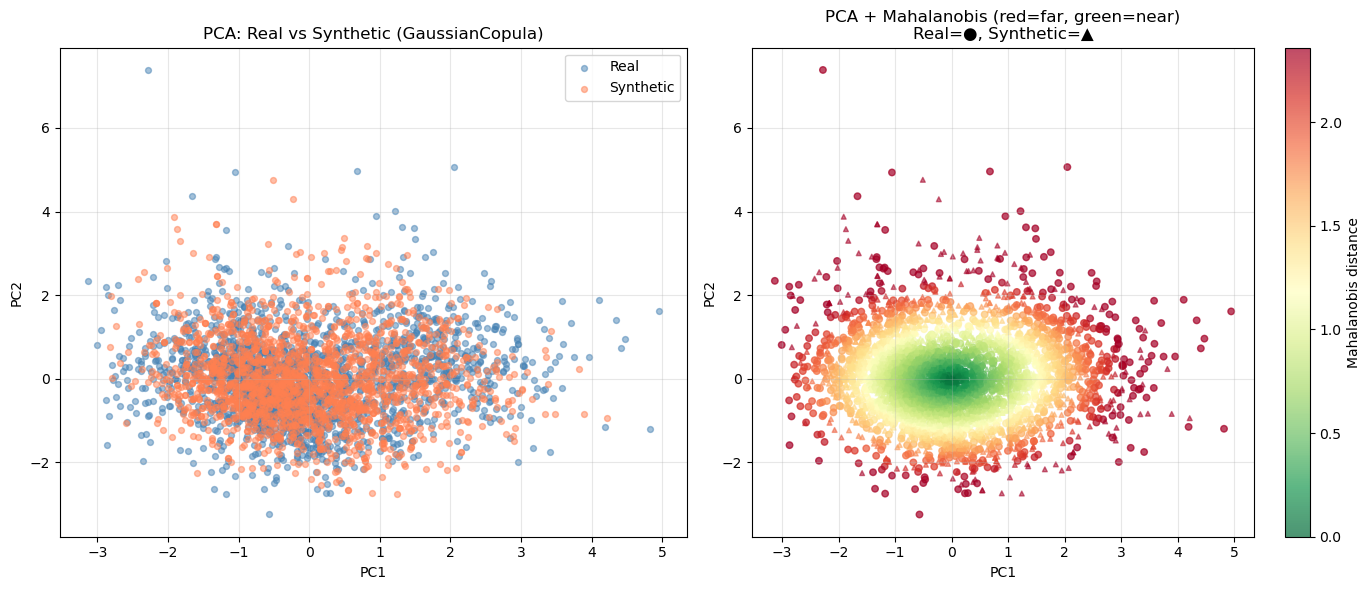

Real   — mean Mahalanobis (PCA 2D): 1.2324
Synth  — mean Mahalanobis (PCA 2D): 1.1561


In [29]:
def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum('ij,jk,ik->i', delta, inv_cov, delta), 0))

# Reuse PCA from previous cell (same model_name)
mu_z   = np.mean(Z_r, axis=0)
cov_z  = np.cov(Z_r, rowvar=False)
reg    = 1e-6
try:
    inv_cov_z = inv(cov_z + reg * np.eye(2))
except LinAlgError:
    inv_cov_z = inv(cov_z + 10 * reg * np.eye(2))

d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(Z_r[:, 0], Z_r[:, 1], c='steelblue', alpha=0.5, s=18, label='Real')
ax.scatter(Z_s[:, 0], Z_s[:, 1], c='coral',     alpha=0.5, s=18, label='Synthetic')
ax.set_title(f'PCA: Real vs Synthetic ({model_name})')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
vmax = np.percentile(np.hstack([d_r, d_s]), 95)
sc = ax.scatter(Z_r[:, 0], Z_r[:, 1], c=d_r, cmap='RdYlGn_r', alpha=0.7, s=22, marker='o', vmin=0, vmax=vmax)
     
ax.scatter(Z_s[:, 0], Z_s[:, 1], c=d_s, cmap='RdYlGn_r', alpha=0.55, s=12, marker='^', vmin=0, vmax=vmax)
plt.colorbar(sc, ax=ax, label='Mahalanobis distance')
ax.set_title('PCA + Mahalanobis (red=far, green=near)\nReal=●, Synthetic=▲')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Real   — mean Mahalanobis (PCA 2D): {d_r.mean():.4f}')
print(f'Synth  — mean Mahalanobis (PCA 2D): {d_s.mean():.4f}')